# Customer Churn Prediction using Machine Learning

## Project Overview

Customer churn is one of the biggest challenges faced by subscription-based businesses such as telecom providers. Acquiring a new customer is significantly more expensive than keeping an existing one. Therefore, accurately identifying customers who are likely to leave enables companies to take proactive retention measures.

In this project, an end-to-end machine learning pipeline is developed to predict customer churn using the Telco Customer Churn dataset. Multiple classification models are trained and evaluated before selecting the best performing model. The final model is deployed in an interactive Streamlit dashboard that provides churn probability, business recommendations, customer value estimation, and SHAP-based Explainable AI for transparent predictions.

## 1. Import Required Libraries

The following libraries are imported for data manipulation, visualization, machine learning, model evaluation, explainability, and deployment.

In [41]:
# Numerical computing and Data manipulation
import numpy as np
import pandas as pd

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Data splitting and hyperparameter tuning
from sklearn.model_selection import train_test_split, GridSearchCV

# Data preprocessing
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler

# Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier

# Evaluation Metrics
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, r2_score, roc_auc_score, accuracy_score, precision_score, recall_score, f1_score

# Handling class imbalance
from imblearn.combine import SMOTEENN 

# Model Explainability
import shap as sh

# Model saving
import joblib as jl

import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

%matplotlib inline

# 2. Load the Dataset

In [42]:
df=pd.read_csv("../data/raw/Telco-Customer-Churn.csv")
df.head() # Display the first five rows

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# 3. Initial Data Inspection

In [43]:
df.info()  # Display information about the DataFrame like column names, data types, and non-null counts

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [44]:
df.describe()  # Display summary statistics for numerical columns

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [45]:
df.describe(include="object")  # Display summary statistics for categorical columns

C:\Users\hp\AppData\Local\Temp\ipykernel_11056\641639791.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")  # Display summary statistics for categorical columns


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


# 4. Data Cleaning

Clean and prepare the dataset for machine learning.

In [46]:
df=df.replace(" ", np.nan) # replace empty strings with NaN values
df.isnull().sum() # Identify the number of NaN  values for each column in the DataFrame

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [47]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce') # Convert the 'TotalCharges' column to numeric, coercing errors to NaN
df=df.dropna() # Remove rows with any remaining NaN values

In [48]:
df.info() # Display information about the DataFrame after cleaning to check for data types

<class 'pandas.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   str    
 1   gender            7032 non-null   str    
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   str    
 4   Dependents        7032 non-null   str    
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   str    
 7   MultipleLines     7032 non-null   str    
 8   InternetService   7032 non-null   str    
 9   OnlineSecurity    7032 non-null   str    
 10  OnlineBackup      7032 non-null   str    
 11  DeviceProtection  7032 non-null   str    
 12  TechSupport       7032 non-null   str    
 13  StreamingTV       7032 non-null   str    
 14  StreamingMovies   7032 non-null   str    
 15  Contract          7032 non-null   str    
 16  PaperlessBilling  7032 non-null   str    
 17  PaymentMeth

In [49]:
df=df.drop('customerID', axis=1) # Drop the 'customerID' column as it is not useful for prediction

In [50]:
df.to_csv("../data/processed/Telco-Customer-Churn.csv", index=False) # Save the cleaned DataFrame to a new CSV file in the processed data directory

In [51]:
df["Churn"].value_counts()/len(df["Churn"])*100 # Calculate the percentage distribution of churn classes

Churn
No     73.421502
Yes    26.578498
Name: count, dtype: float64

Approximately **73%** of customers did not churn, while **27%** churned.

This indicates a moderate class imbalance, which can negatively impact model performance if left untreated. To address this issue during model training, SMOTEENN resampling will be applied later in the workflow.

# 5. Exploratory Data Analysis (EDA)
The following analysis focuses on understanding the distribution of the target variable, feature relationships, and business insights that can guide feature engineering and model development.

### Churn distribution across genders

<Axes: xlabel='gender', ylabel='count'>

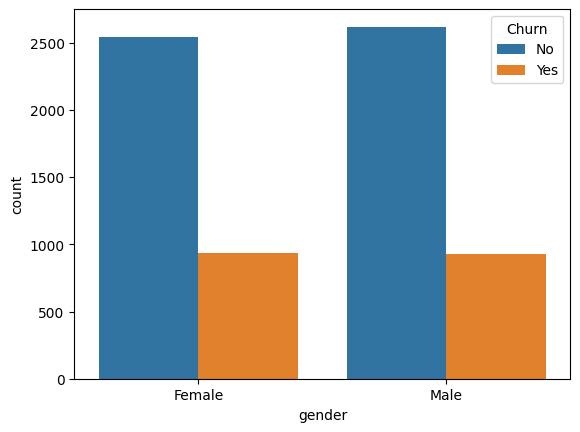

In [52]:
sns.countplot(data=df, x='gender', hue='Churn')

The churn distribution is nearly identical for male and female customers. This suggests that gender has little influence on customer churn and is unlikely to be a strong standalone predictor.

### Senior Citizen vs Churn counts

<Axes: xlabel='SeniorCitizen', ylabel='count'>

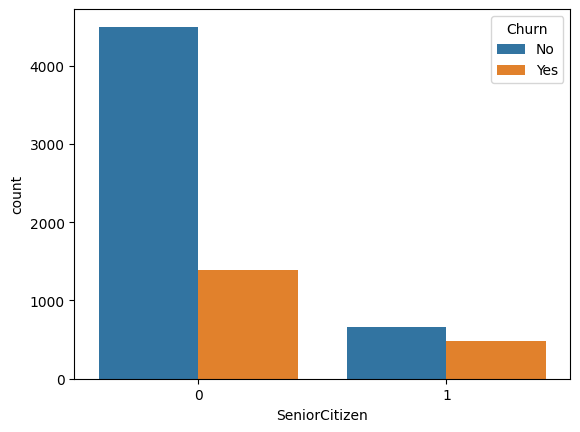

In [53]:
sns.countplot(data=df, x='SeniorCitizen', hue='Churn')

Although senior citizens represent a smaller portion of the customer base, they show a relatively higher proportion of churn. This suggests that senior customers may require additional retention efforts.

### Dependents vs Churn count

<Axes: xlabel='Dependents', ylabel='count'>

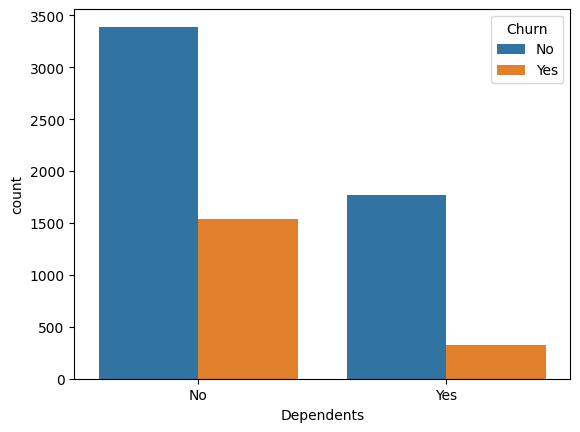

In [54]:
sns.countplot(data=df, x='Dependents', hue='Churn')

Customers without dependents churn considerably more often than customers with dependents.

### Partner vs Churn count

<Axes: xlabel='Partner', ylabel='count'>

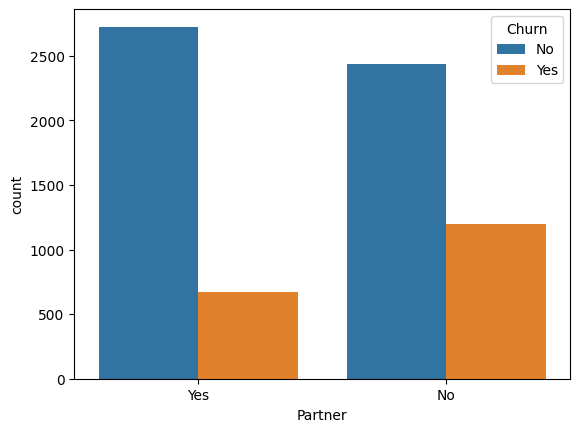

In [55]:
sns.countplot(data=df, x='Partner', hue='Churn')

Customers without partners shows noticeably higher churn than those with partners, suggesting that customers with partners tend to remain with the service longer.

### Contract type vs Churn count

<Axes: xlabel='Contract', ylabel='count'>

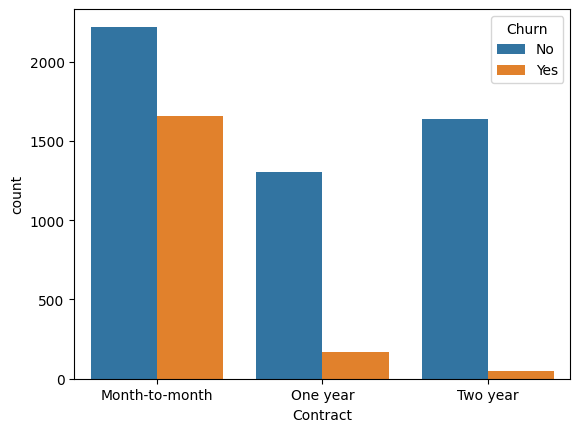

In [56]:
sns.countplot(data=df, x='Contract', hue='Churn')

Customers on month-to-month contracts show the highest churn while customers with one-year and two-year contracts are more likely to remain with the company. Contract type appears to be one of the strongest predictors of churn.

### Payment method vs Churn count

<Axes: xlabel='PaymentMethod', ylabel='count'>

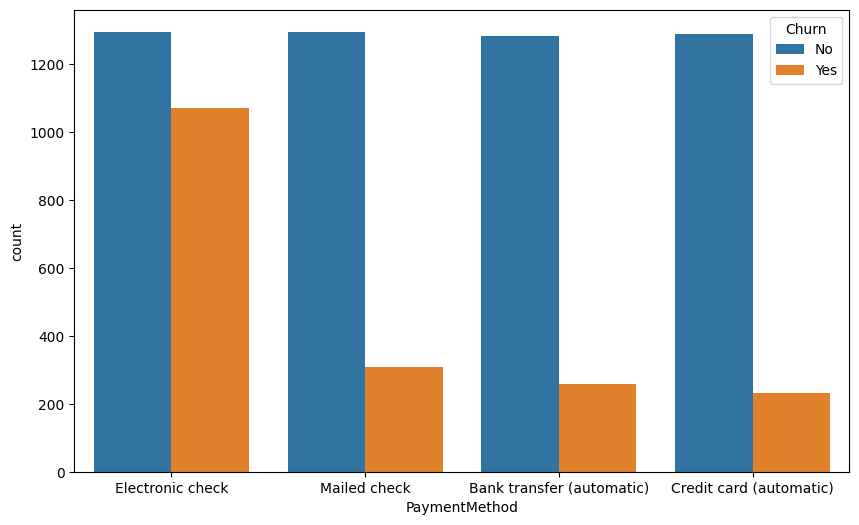

In [57]:
plt.figure(figsize=(10,6))
sns.countplot(data=df, x='PaymentMethod', hue='Churn')


Customers paying through electronic checks show considerably higher churn than customers using payment methods such as bank transfers or credit cards.

### Tech Support vs Churn count

<Axes: xlabel='TechSupport', ylabel='count'>

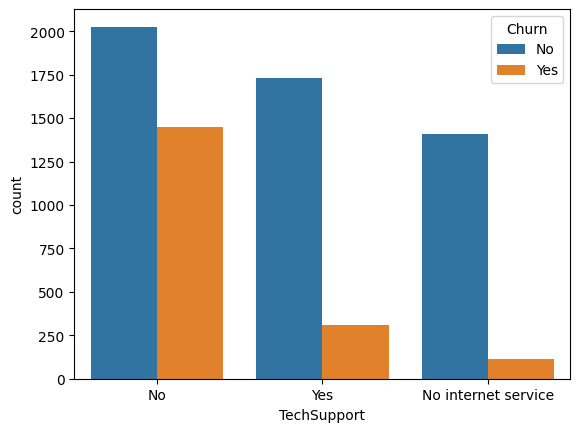

In [58]:
sns.countplot(data=df, x='TechSupport', hue='Churn')

customers without Tech Support show a higher churn than those who subscribe to the service. Providing effective technical support may play an important role in customer retention.

### Tenure Distribution by Churn

<Axes: xlabel='tenure', ylabel='Count'>

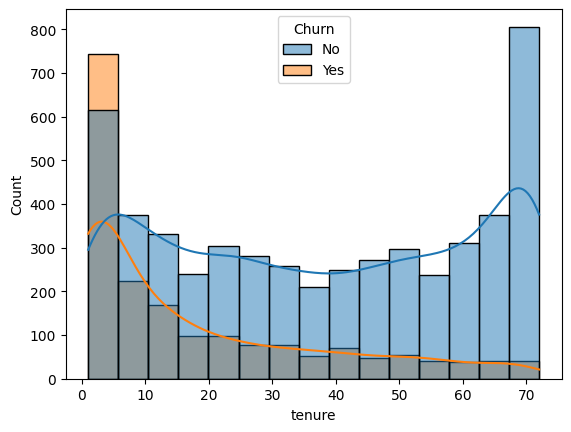

In [59]:
sns.histplot(df, x='tenure',hue='Churn', kde=True)

Customers who churn are concentrated within the early months of their subscription, while long-tenure customers are significantly more likely to stay. Customer loyalty appears to strengthen as tenure increases.

### Pairplot
Pairwise Relationship Between Numerical Features

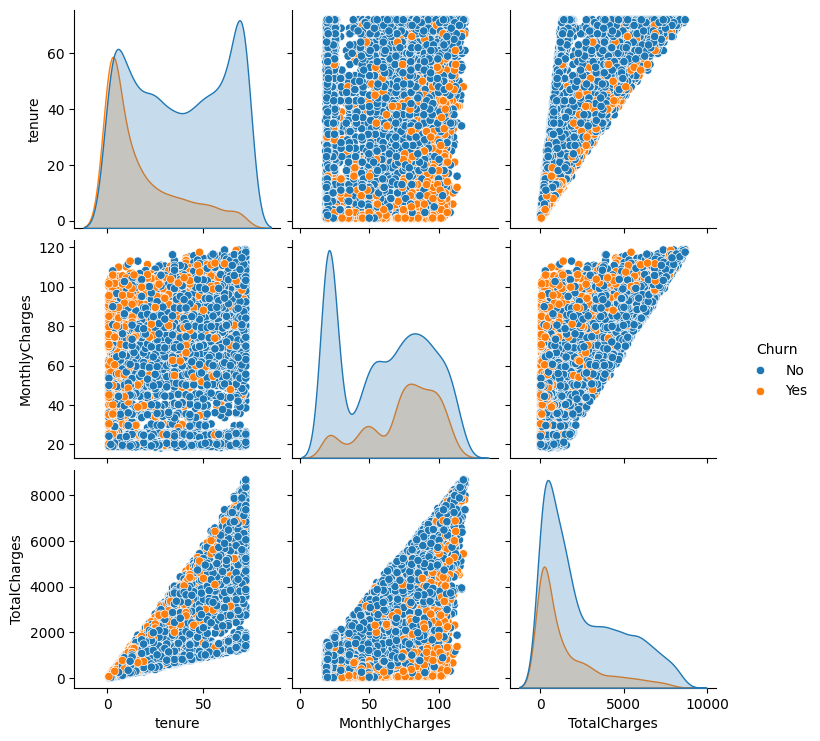

In [60]:
sns.pairplot(df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']], hue='Churn')

Churned customers (orange) are concentrated at lower tenure values.
Customers with longer tenure are predominantly retained.

### Boxplots
Distribution of Numerical Features by Churn Status

<Axes: xlabel='Churn', ylabel='tenure'>

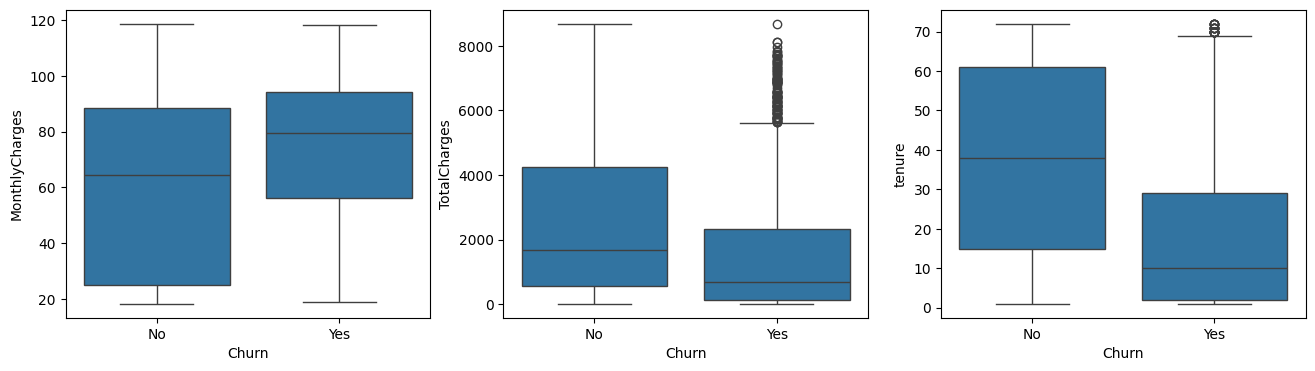

In [61]:
plt.figure(figsize=(16,4))
plt.subplot(1,3,1)
sns.boxplot(y='MonthlyCharges', x='Churn', data=df)

plt.subplot(1,3,2)
sns.boxplot(y='TotalCharges', x='Churn', data=df)

plt.subplot(1,3,3)
sns.boxplot(y='tenure', x='Churn', data=df)

Churned customers generally pay higher monthly charges than retained customers.
Customers who churn typically have much shorter tenure, confirming tenure as one of the strongest predictors of churn.

### Correlation Heatmap
Correlation of numerical features with churn

<Axes: >

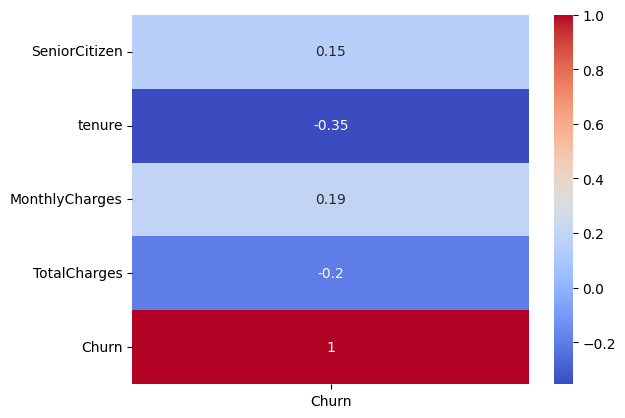

In [62]:
df['Churn']=df['Churn'].map({'Yes':1, 'No':0})
numeric_df=df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr()[['Churn']], annot=True, cmap="coolwarm")

No single numerical feature is highly correlated with churn, highlighting the need for machine learning models to capture more complex relationships. Tenure has the strongest negative correlation with churn (-0.35), meaning longer-term customers are less likely to leave.

### Crosstab Analysis
Churn Percentage Across Key Customer Segments

In [63]:
print(pd.crosstab(df['Contract'], df['Churn'], normalize='index')*100)
print("-----------------------------------------------------")
print(pd.crosstab(df['PaymentMethod'], df['Churn'], normalize='index')*100)
print("-----------------------------------------------------")
print(pd.crosstab(df['InternetService'], df['Churn'], normalize='index')*100)
print("-----------------------------------------------------")
print(pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index')*100)
print("-----------------------------------------------------")
print(pd.crosstab(df['PaperlessBilling'], df['Churn'], normalize='index')*100)


Churn                   0          1
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665
-----------------------------------------------------
Churn                              0          1
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995
-----------------------------------------------------
Churn                    0          1
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211
-----------------------------------------------------
Churn                        0          1
OnlineSecurity                           
No                   58.221333  41.778667
No internet service  92.565789   7.434211
Yes    

Month-to-month contracts have the highest churn rate (~43%), while two-year contracts have the lowest (~3%).
Customers using Electronic Check show the highest churn (~45%).
Fiber optic customers churn more frequently than any other internet services.
Customers without Online Security are more likely to churn.
Paperless billing users show a higher churn rate than customers receiving paper bills.

These findings suggest that contract type and service choices strongly influence customer retention.

### Business Insights

1. Customer churn rate is approximately 27%.
2. Month-to-month contracts have the highest churn risk.
3. Customers with shorter tenure are significantly more likely to churn.
4. Customers without Online Security or Tech Support show higher churn rates.

# 6. Data Preparation for Machine Learning

In this section, the cleaned dataset is transformed into a machine learning-ready format. Categorical variables are encoded, numerical features are standardized, and the data is prepared for model training and evaluation.

In [64]:
data_dummies=pd.get_dummies(df) # Convert categorical variables into numerical features using one-hot encoding
data_dummies.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Female,gender_Male,Partner_No,Partner_Yes,Dependents_No,...,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaperlessBilling_No,PaperlessBilling_Yes,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,True,False,False,True,True,...,False,True,False,False,False,True,False,False,True,False
1,0,34,56.95,1889.50,0,False,True,True,False,True,...,False,False,True,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,False,True,True,False,True,...,False,True,False,False,False,True,False,False,False,True
3,0,45,42.30,1840.75,0,False,True,True,False,True,...,False,False,True,False,True,False,True,False,False,False
4,0,2,70.70,151.65,1,True,False,True,False,True,...,False,True,False,False,False,True,False,False,True,False


### Feature Correlation with Churn

<Axes: >

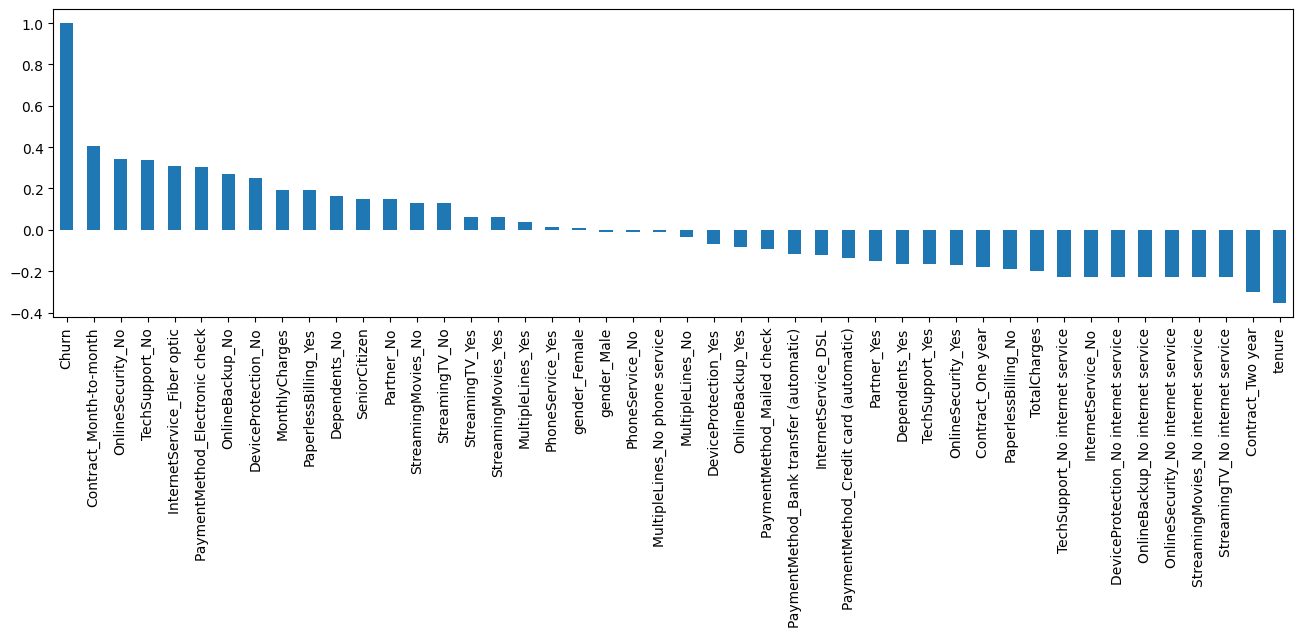

In [65]:
plt.figure(figsize=(16,4))
data_dummies.corr()['Churn'].sort_values(ascending=False).plot(kind='bar') # Plot correlation of each feature with the target variable

# 7. Data Preprocessing 

In [66]:
# Separate independent features and target variable
X=data_dummies.drop('Churn', axis=1)
y=data_dummies['Churn']
X.dropna()
y.value_counts() #class distribution of target variable

Churn
0    5163
1    1869
Name: count, dtype: int64

### Feature Scaling

Numerical features are standardized to improve the performance of distance-based and gradient-based machine learning algorithms.

In [67]:
transform = preprocessing.StandardScaler()
X=transform.fit_transform(X)

feature_names=data_dummies.drop("Churn", axis=1).columns


###  Train-Test Split

The dataset is divided into training and testing subsets to evaluate the model's ability to generalize to unseen data.

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y) # Split the data into training and testing sets


Initial experiments on the original dataset showed that the models were biased toward the majority (non-churn) class.

To improve the model's ability to identify churning customers, SMOTEENN was applied to the training dataset only. This approach combines synthetic oversampling (SMOTE) with data cleaning (Edited Nearest Neighbours), producing a more balanced and informative training set while leaving the test set untouched for unbiased evaluation.

In [69]:
sm=SMOTEENN(random_state=42)
X_res, y_res= sm.fit_resample(X_train,y_train)

### Confusion matrix function

In [70]:
def plot_confusion_matrix(y,y_predict):
    "this function plots the confusion matrix"
    from sklearn.metrics import confusion_matrix

    cm = confusion_matrix(y, y_predict)
    ax= plt.subplot()
    sns.heatmap(cm, annot=True, ax = ax, fmt='d'); #annot=True to annotate cells
    ax.set_xlabel('Predicted labels')
    ax.set_ylabel('True labels')
    ax.set_title('Confusion Matrix'); 
    ax.xaxis.set_ticklabels(['did not churn', 'churn']); ax.yaxis.set_ticklabels(['did not churn', 'churn']) 
    plt.show() 

# 8. Model Training & Hyperparameter Optimization

To identify the most effective classifier for customer churn prediction, multiple machine learning algorithms were trained and evaluated.

Each model was tuned using **GridSearchCV** with cross-validation to obtain the optimal hyperparameters while reducing the risk of overfitting. Since the training data was balanced using **SMOTEENN**, all models were trained on the resampled training set and evaluated on the untouched test set.

## XGBoost Classifier

XGBoost is an ensemble boosting algorithm that builds decision trees sequentially, with each tree correcting the errors made by the previous ones. It is widely recognized for delivering strong predictive performance on structured tabular datasets.

Fitting 5 folds for each of 108 candidates, totalling 540 fits


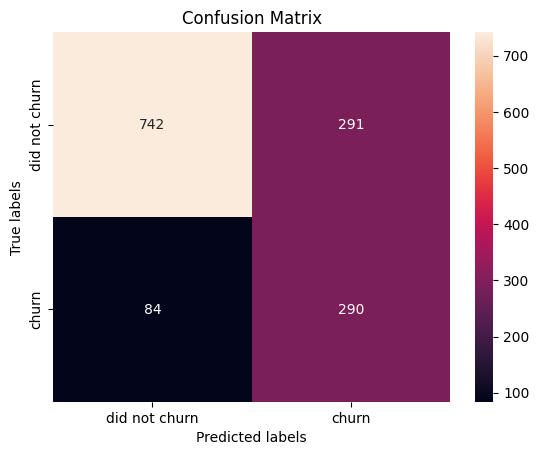

Classification report for xgb :
               precision    recall  f1-score   support

           0       0.90      0.72      0.80      1033
           1       0.50      0.78      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.79      0.73      0.75      1407

ROC-AUC : 0.7468486470536466


In [71]:
xgb=XGBClassifier(objective='binary:logistic', eval_metric='logloss',random_state=42)
param={'max_depth': [3,5,7], 'n_estimators': [100, 200, 300], 'learning_rate': [0.01, 0.05, 0.1], 'subsample': [0.8, 0.9], 'colsample_bytree':[0.8, 0.9]}
grid_xgb=GridSearchCV(estimator=xgb, param_grid=param, scoring='f1', cv=5, n_jobs=-1, verbose=2)
grid_xgb.fit(X_res, y_res)
best_xgb=grid_xgb.best_estimator_
yhat1_xgb=best_xgb.predict(X_test)

#Model evaluation
plot_confusion_matrix(y_test,yhat1_xgb)
print("Classification report for xgb :\n", classification_report(y_test, yhat1_xgb)) 
print("ROC-AUC :", roc_auc_score(y_test,yhat1_xgb))


## Decision Tree Classifier

Decision Trees are simple and interpretable machine learning models that recursively split the data based on feature values. Hyperparameter tuning was performed to control tree complexity and reduce overfitting.


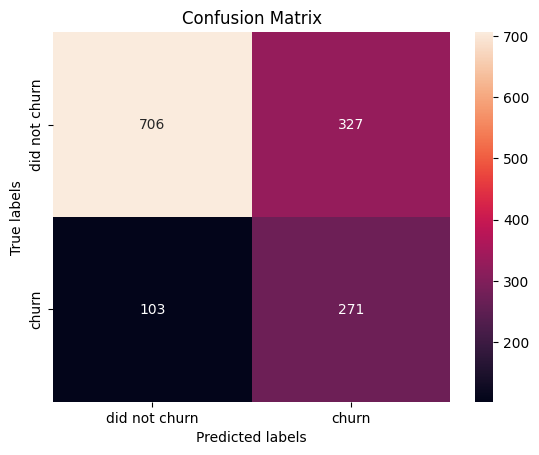

Classification report for decession tree :
               precision    recall  f1-score   support

           0       0.87      0.68      0.77      1033
           1       0.45      0.72      0.56       374

    accuracy                           0.69      1407
   macro avg       0.66      0.70      0.66      1407
weighted avg       0.76      0.69      0.71      1407

ROC-AUC : 0.7040226017362855


In [72]:
parameters = {'criterion': ['gini', 'entropy'],
     'splitter': ['best', 'random'],
     'max_depth': [2*n for n in range(1,10)],
     'max_features': ['sqrt'],
     'min_samples_leaf': [1, 2, 4],
     'min_samples_split': [2, 5, 10]}

tree = DecisionTreeClassifier(class_weight='balanced')
tree_cv=GridSearchCV(estimator=tree, param_grid=parameters, cv=10)
tree_cv.fit(X_res, y_res)

#Model evaluation
yhat_tree = tree_cv.predict(X_test)
plot_confusion_matrix(y_test,yhat_tree)
print("Classification report for decession tree :\n", classification_report(y_test, yhat_tree))
print("ROC-AUC :", roc_auc_score(y_test,yhat_tree))

## Random Forest Classifier

Random Forest combines multiple decision trees using bagging to improve generalization and reduce overfitting. Grid Search was used to identify the optimal combination of tree depth, number of estimators, and splitting criteria.

Fitting 5 folds for each of 216 candidates, totalling 1080 fits


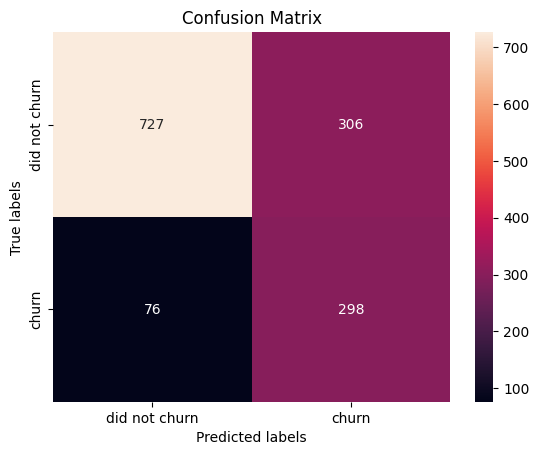

Classification report for random forest :
               precision    recall  f1-score   support

           0       0.91      0.70      0.79      1033
           1       0.49      0.80      0.61       374

    accuracy                           0.73      1407
   macro avg       0.70      0.75      0.70      1407
weighted avg       0.80      0.73      0.74      1407

ROC-AUC : 0.7502834276366536


In [73]:
param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42)
grid_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    verbose=2
)

grid_rf.fit(X_res, y_res)

#Model evaluation
best_rf=grid_rf.best_estimator_
y_pred1_rf=best_rf.predict(X_test)
plot_confusion_matrix(y_test,y_pred1_rf)
print("Classification report for random forest :\n", classification_report(y_test, y_pred1_rf))
print("ROC-AUC :", roc_auc_score(y_test,y_pred1_rf))


## Logistic Regression

Logistic Regression serves as a strong baseline linear classifier for binary classification problems. Hyperparameter tuning was performed to identify the optimal regularization strength while using balanced class weights.

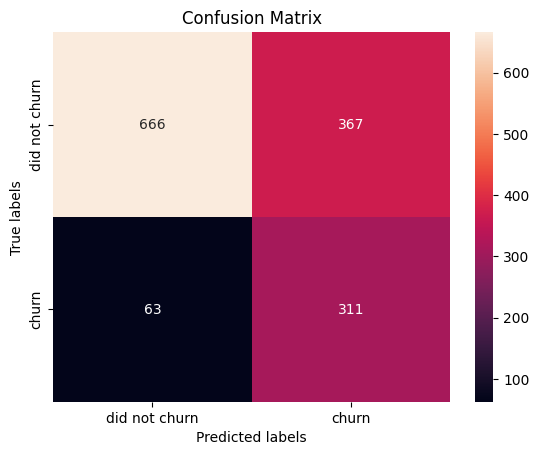

Classification report for Logistic Regression : 
               precision    recall  f1-score   support

           0       0.91      0.64      0.76      1033
           1       0.46      0.83      0.59       374

    accuracy                           0.69      1407
   macro avg       0.69      0.74      0.67      1407
weighted avg       0.79      0.69      0.71      1407

ROC-AUC : 0.7381374533444461


In [74]:
parameters ={"C":[0.01,0.1,1],'penalty':['l2'], 'solver':['lbfgs']}# l1 lasso l2 ridge
lr1=LogisticRegression(class_weight='balanced')

logreg1_cv=GridSearchCV(estimator=lr1, param_grid=parameters,cv=10, scoring='f1_weighted') 
logreg1_cv.fit(X_res, y_res)

yhat1_lr=logreg1_cv.predict(X_test)

#Model evaluation
plot_confusion_matrix(y_test,yhat1_lr)
print("Classification report for Logistic Regression : \n", classification_report(y_test, yhat1_lr))
print("ROC-AUC :", roc_auc_score(y_test,yhat1_lr))

# 9. Model Performance Comparison

To objectively compare the classifiers, the best-performing version of each tuned model was evaluated on the unseen test dataset.

The comparison includes Accuracy, Precision, Recall, F1-Score, and ROC-AUC, providing a comprehensive assessment of each model's predictive performance.

In [75]:
results = []
models = {
    "Logistic Regression": logreg1_cv,
    "Decision Tree": tree_cv,
    "Random Forest": best_rf,
    "XGBoost": best_xgb
}
for name, model in models.items():

    # Predictions
    y_pred = model.predict(X_test)

    # Probability predictions
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    })

comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by="ROC-AUC",
    ascending=False
).round(4)


comparison_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.6944,0.4587,0.8316,0.5913,0.8236
3,XGBoost,0.7335,0.4991,0.7754,0.6073,0.8205
2,Random Forest,0.7285,0.4934,0.7968,0.6094,0.8204
1,Decision Tree,0.6944,0.4532,0.7246,0.5576,0.7025


# 10. Final Model Selection

After comparing all models, **Random Forest** was selected as the final model for customer churn prediction.

The model achieved the **highest F1-Score (0.6094)** among all evaluated classifiers while maintaining a **high Recall (79.68%)**, **strong Accuracy (72.85%)**, and a **ROC-AUC (0.8204)** that was nearly identical to XGBoost (0.8205).

Although XGBoost achieved a marginally higher Accuracy (73.35%) and ROC-AUC (0.8205), the improvements were negligible. Random Forest demonstrated a better overall balance between Precision and Recall, resulting in the highest F1-Score, which is particularly important for an imbalanced customer churn prediction problem.

Therefore, Random Forest was selected as the final model because it provides the most balanced predictive performance while remaining robust, interpretable, and computationally efficient.

# 11. Model Explainability with SHAP

Although Random Forest achieved the best predictive performance, understanding **why** the model makes its predictions is equally important. SHAP (SHapley Additive exPlanations) was used to interpret the contribution of each feature toward the model's predictions.

The following visualizations provide both global and local explanations, helping identify the most influential factors driving customer churn.

## Global Feature Importance using SHAP

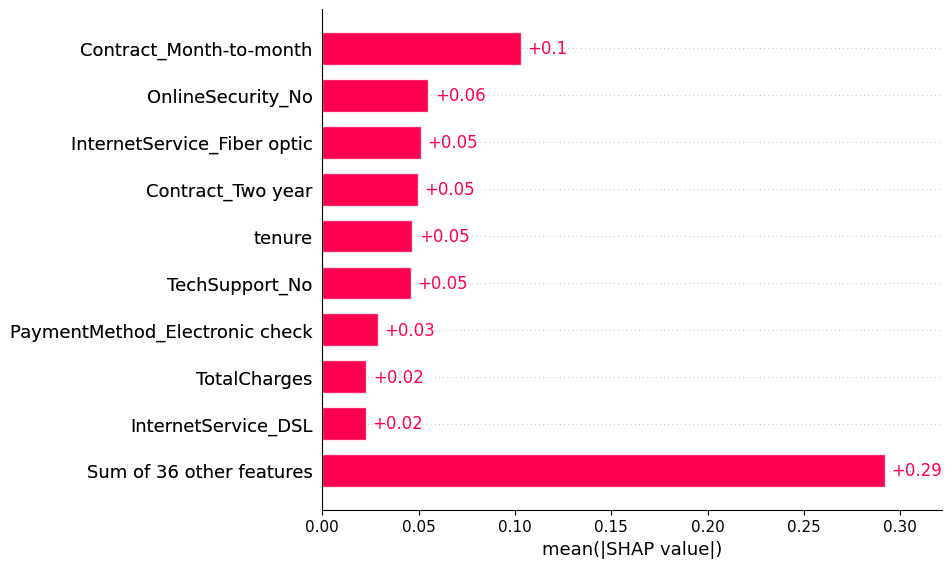

In [76]:
X_test_df=pd.DataFrame(X_test, columns=feature_names)
explainer= sh.TreeExplainer(best_rf)
shap_values=explainer(X_test_df)
sh.plots.bar(shap_values[:,:,1])

### Interpretation

The SHAP feature importance plot ranks variables according to their average impact on the model's predictions.

Key observations:

- Month-to-month contracts have the strongest influence on churn prediction.
- Customers without Online Security or Tech Support contribute significantly to higher churn.
- Fiber optic internet service is also an important predictor of churn.
- Contract duration and customer tenure strongly influence customer retention.

These findings closely align with the insights discovered during the exploratory data analysis.

## SHAP Summary Plot

The SHAP summary plot illustrates both feature importance and the direction of their impact.

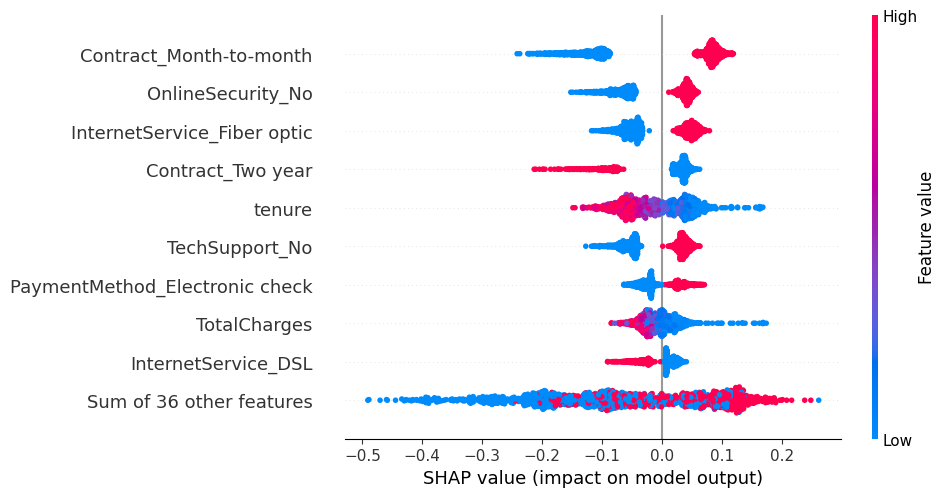

In [77]:
sh.plots.beeswarm(shap_values[:,:,1])

## SHAP Waterfall Plot for an Individual Prediction

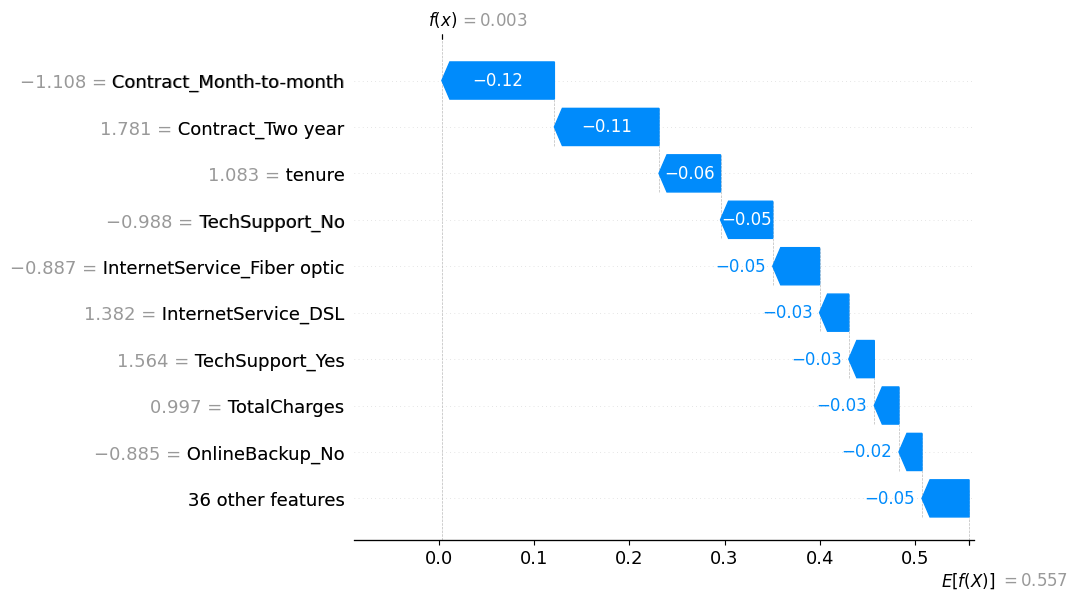

In [78]:
sh.plots.waterfall(shap_values[:,:,1][0])

### Interpretation

The waterfall plot explains how individual features influenced the prediction for a single customer.

Starting from the model's baseline prediction, each feature either increased or decreased the predicted probability of churn.

For this customer:

- Contract type had the largest impact on the prediction.
- Customer tenure reduced the likelihood of churn.
- Internet service type and technical support also contributed to the final prediction.
- The cumulative contribution of all features produced the model's final churn probability for this customer.

This level of interpretability makes the model suitable for real-world business applications where prediction transparency is essential.

# 12. Saving the Final Model

The trained Random Forest model, feature scaler, and feature column names were saved using Joblib.

Saving these artifacts ensures that the exact preprocessing pipeline and trained model can be reused later for deployment in the Streamlit application without retraining.

In [79]:
jl.dump(best_rf, "model.pkl")

jl.dump(transform, "scaler.pkl")

feature_names=data_dummies.drop("Churn",axis=1).columns.tolist()
jl.dump(feature_names, "feature_columns.pkl")


['feature_columns.pkl']